# **Feature Extraction: Linear Methods:**

## **PCA**

- Linear
- Unsupervised
- Projection-based Method


n_components: n_original_features

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

In [2]:
data = load_wine()

X, y = data['data'], data['target']
wine = pd.DataFrame(data=X, columns=data['feature_names'])
wine['target'] = y

wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [3]:
# scaling the data, scaling is important in dimenstionality reduction techniques
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'Second Principal Component')

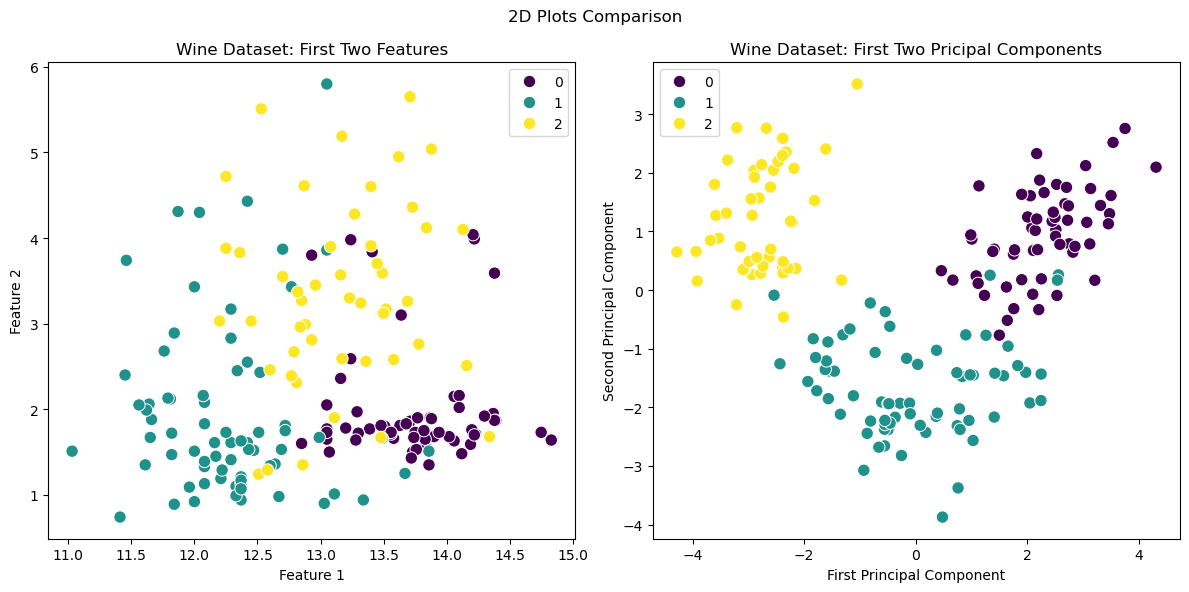

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
plt.suptitle("2D Plots Comparison")

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=80, ax=ax1, palette="viridis")

ax1.set_title("Wine Dataset: First Two Features")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, s=80, ax=ax2, palette="viridis")

ax2.set_title("Wine Dataset: First Two Pricipal Components")
ax2.set_xlabel("First Principal Component")
ax2.set_ylabel("Second Principal Component")

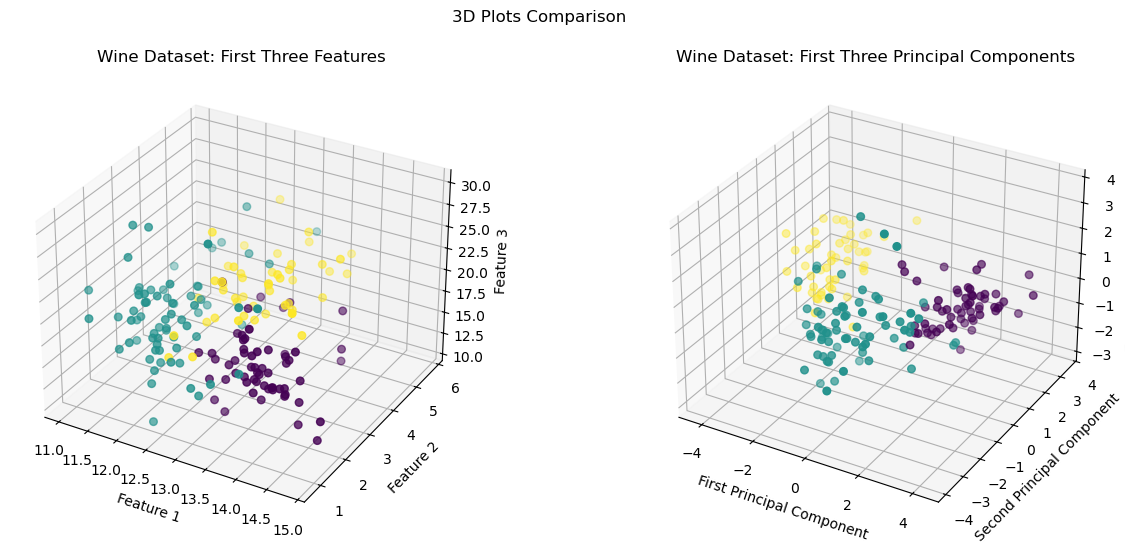

In [5]:
plt.figure(figsize=(15, 6))
plt.suptitle("3D Plots Comparison")

ax1 = plt.subplot(121, projection="3d")
ax1.scatter(xs=X[:, 0], ys=X[:, 1], zs=X[:, 3], c=y, s=30)
ax1.set(
    title="Wine Dataset: First Three Features",
    xlabel="Feature 1",
    ylabel="Feature 2",
    zlabel="Feature 3"
)

ax2 = plt.subplot(122, projection="3d")
ax2.scatter(xs=X_pca[:, 0], ys=X_pca[:, 1], zs=X_pca[:, 3], c=y, s=30)
ax2.set(
    title="Wine Dataset: First Three Principal Components",
    xlabel="First Principal Component",
    ylabel="Second Principal Component",
    zlabel="Third Principal Component"
)

plt.show()

We can see using PCA we found the components that are the linear combination of the features in the dataset and ordered in descending order by the variance the have (bigger variance means bigger eigenvalue based-on the calculus of variations). So using just first three principal components extracted we can cluster of classify the data for each type of flower instead of using first three features in the original dataset.

In [6]:
X_pca.shape

(178, 13)

In [7]:
components_loadings = pd.DataFrame(
    data=np.abs(pca.components_.T),
    index=data['feature_names'],
    columns=[f"PC{i+1}" for i in range(pca.n_features_in_)]
)

components_loadings.style.highlight_max(axis=0, props="background-color: green; color: black")

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
alcohol,0.144329,0.483652,0.207383,0.017856,0.265664,0.213539,0.056396,0.396139,0.508619,0.211605,0.225917,0.266286,0.014970
malic_acid,0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,0.309080,0.076486,0.121696,0.025964
ash,0.002051,0.316069,0.626224,0.214176,0.143025,0.154475,0.149171,0.170260,0.307694,0.027125,0.498691,0.049622,0.141218
alcalinity_of_ash,0.239320,0.010591,0.612080,0.060859,0.066103,0.100825,0.286969,0.427970,0.200449,0.052799,0.479314,0.055743,0.091683
magnesium,0.141992,0.299634,0.130757,0.351797,0.727049,0.038144,0.322883,0.156361,0.271403,0.067870,0.071289,0.062220,0.056774
total_phenols,0.394661,0.065040,0.146179,0.198068,0.149318,0.084122,0.027925,0.405934,0.286035,0.320131,0.304341,0.303882,0.463908
flavanoids,0.422934,0.003360,0.150682,0.152295,0.109026,0.018920,0.060685,0.187245,0.049578,0.163151,0.025694,0.042899,0.832257
nonflavanoid_phenols,0.298533,0.028779,0.170368,0.203301,0.500703,0.258594,0.595447,0.233285,0.195501,0.215535,0.116896,0.042352,0.114040
proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860,0.533795,0.372139,0.368227,0.209145,0.134184,0.237363,0.095553,0.116917
color_intensity,0.088617,0.529996,0.137306,0.065926,0.076437,0.418644,0.227712,0.033797,0.056218,0.290775,0.031839,0.604222,0.011993


Text(0.5, 1.0, 'Correlation Matrix')

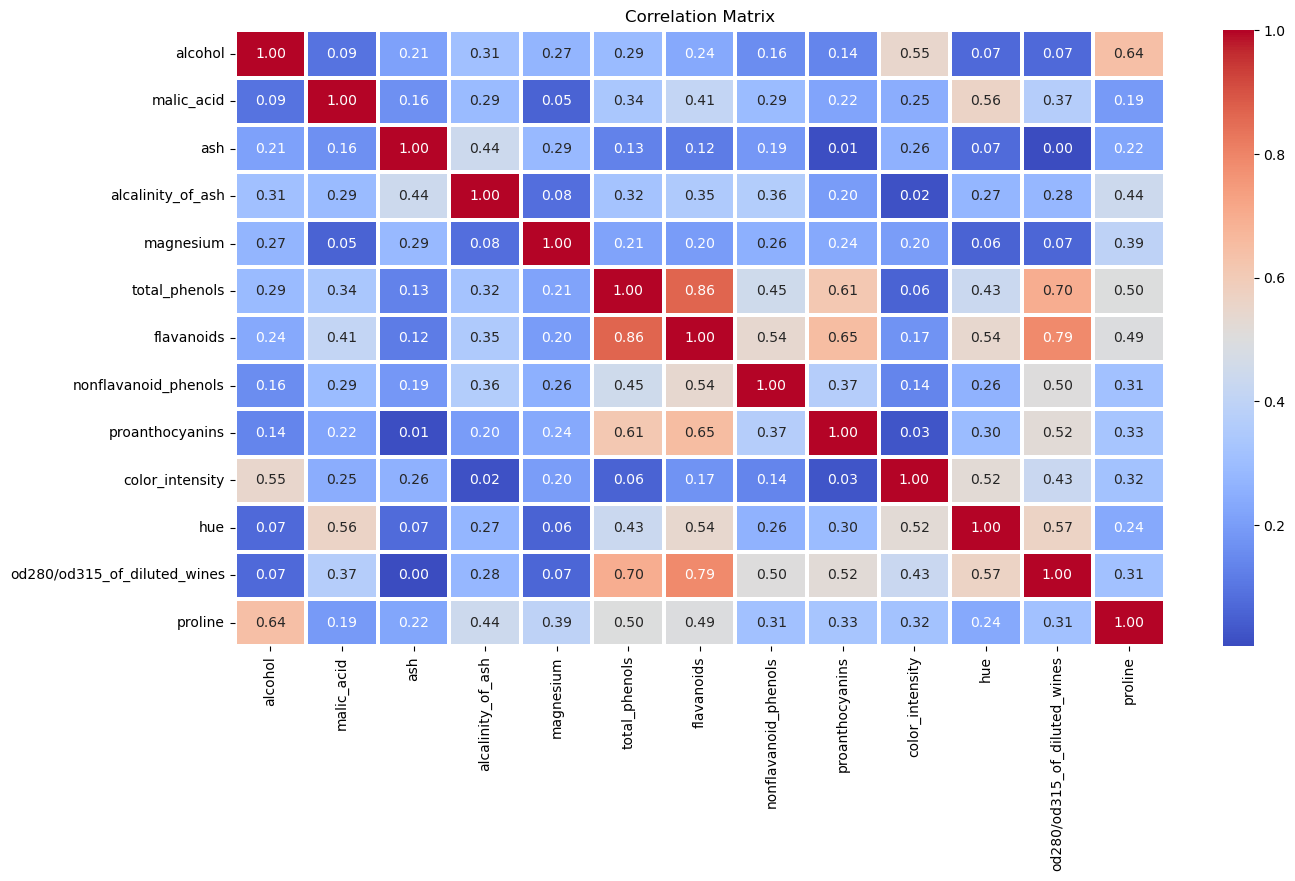

In [8]:
X_df = pd.DataFrame(data=X, columns=data['feature_names'])
correlation_matrix = np.abs(X_df.corr())
plt.figure(figsize=(15, 8))

sns.heatmap(
    data=correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f", linewidths=1.5
)
plt.title("Correlation Matrix")

Text(0.5, 1.0, 'Explained Variance Ration of each PCA Extracted Feature')

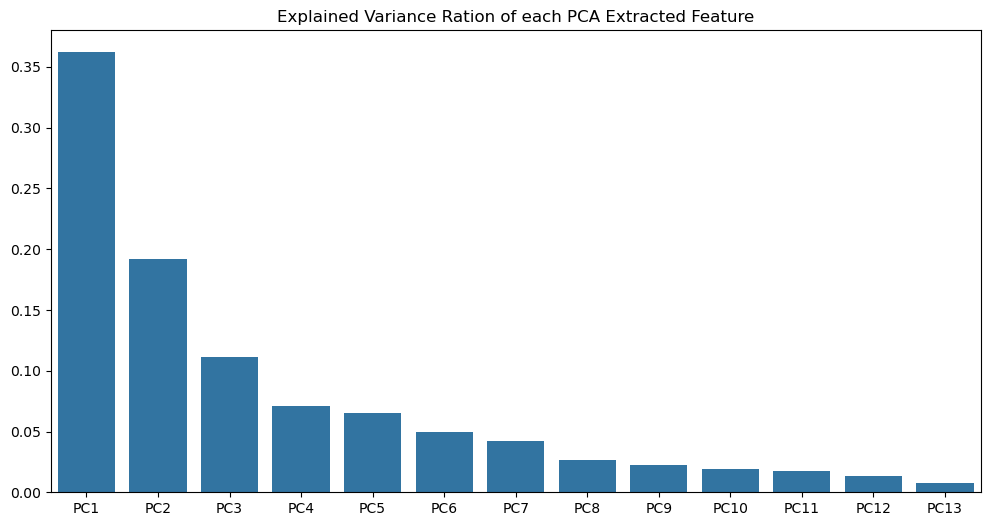

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(x=[f"PC{i + 1}" for i in range(pca.n_components_)], y=pca.explained_variance_ratio_)
plt.title("Explained Variance Ration of each PCA Extracted Feature")

[Text(0.5, 1.0, 'Explained Variance Ration vs. Number of Components'),
 Text(0.5, 0, 'Number of Components'),
 Text(0, 0.5, 'Cumulative Explained Variance Ratio')]

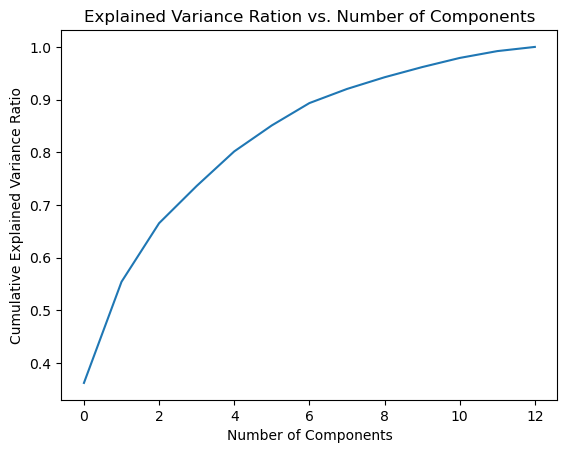

In [10]:
ax = sns.lineplot(data=np.cumsum(pca.explained_variance_ratio_))

ax.set(
    title="Explained Variance Ration vs. Number of Components",
    xlabel="Number of Components",
    ylabel="Cumulative Explained Variance Ratio"
)

Explained variance ration vs. number of components plot used to identify the best value for optimal number of reduced features that can explain the original dataset without a significant loss. It's common to choose number of principal components that describe more than %95 of the variance in the data.

In [11]:
# reconstruction error
rc_error = mean_squared_error(y_true=X_scaled, y_pred=pca.inverse_transform(X_scaled))
print(f"Reconstruction Error: {rc_error}")

Reconstruction Error: 1.5794695755868307


In [12]:
cum_explained_variance_ration = np.cumsum(pca.explained_variance_ratio_) >= 0.95
n_components_95 = np.argmax(cum_explained_variance_ration) + 1
print(f"Number of components explaining %95 of the variance: {n_components_95}")

Number of components explaining %95 of the variance: 10


## **LDA**

- Linear Method
- Supervised
- Project-Based Method

n_components: n_features - 1

This method is a supervised learning method and it can be called a classifier. It's main goal is to maximize the separation of classes by maximizing the ratio of between-cluster distance to within-cluster distance.

> Note: Cause this method sees the labels so after we extract the features using this method - that is more suitable for classification tasks than the pricipal components extracted using PCA - our downstream task becomes more overfitting prone cause in general meeting labels before the training section or during it makes the model more overfitting prone and increases the attention to details of the model so the generalization becomes poor and we should be careful about the bias-variance trade off.

In [13]:
# extracting features from the same dataset (wine)
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)
X_lda.shape

(178, 2)

[Text(0.5, 1.0, 'Wine Dataset: First Two Principal Components'),
 Text(0.5, 0, 'First Principal Component'),
 Text(0, 0.5, 'Second Principal Component')]

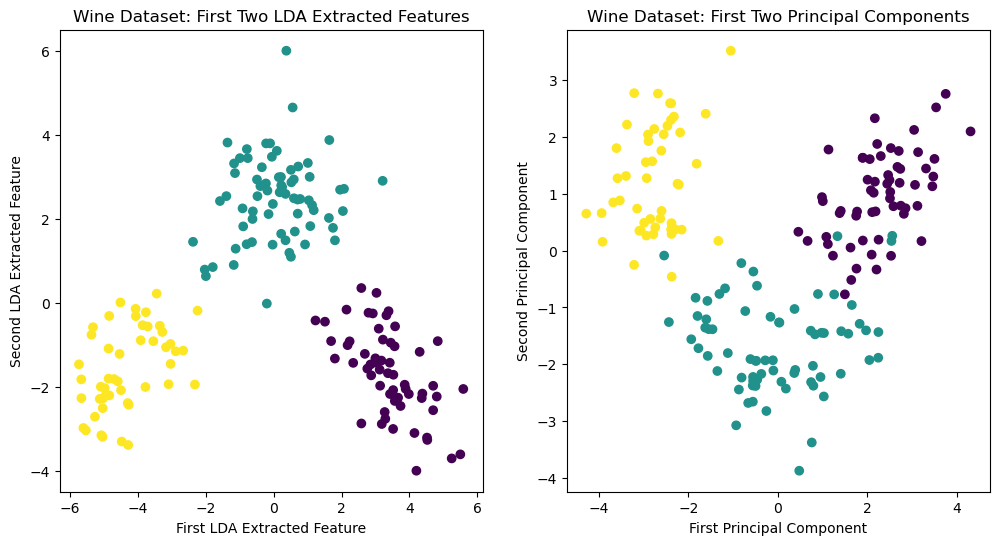

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(X_lda[:, 0], X_lda[:, 1], c=y)
axs[0].set(
    title="Wine Dataset: First Two LDA Extracted Features",
    xlabel="First LDA Extracted Feature",
    ylabel="Second LDA Extracted Feature"
)

axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y)
axs[1].set(
    title="Wine Dataset: First Two Principal Components",
    xlabel="First Principal Component",
    ylabel="Second Principal Component"
)

We see that LDA used the labels and done a supervised task and results in a low dimensional space (2D) than the original 13D space and the clusters are very neat and separate so this feature extraction algorithm is more suitable for the classification tasks with more than 2 clasees (binary classification is not a suitable data for this algorithm cause it will results in just a single feature).

In [15]:
lda.explained_variance_ratio_

array([0.68747889, 0.31252111])

In [16]:
lda.n_features_in_

13

In [17]:
lda.means_

array([[ 0.91919498, -0.29234227,  0.32560449, -0.73799712,  0.4632262 ,
         0.87336224,  0.95688391, -0.57898505,  0.54038332,  0.20340098,
         0.45884745,  0.77135086,  1.17450054],
       [-0.89171997, -0.36236171, -0.44495778,  0.22313708, -0.36456713,
        -0.05806709,  0.05177999,  0.01456883,  0.069002  , -0.85279882,
         0.43361057,  0.24529431, -0.72410998],
       [ 0.18915862,  0.89533073,  0.25794454,  0.57706453, -0.03012665,
        -0.98761685, -1.25276105,  0.6901194 , -0.76628663,  1.01141787,
        -1.20538229, -1.31094994, -0.37257757]])

In [18]:
class_wise_means = pd.DataFrame(lda.means_, columns=data['feature_names'])
class_wise_means

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.919195,-0.292342,0.325604,-0.737997,0.463226,0.873362,0.956884,-0.578985,0.540383,0.203401,0.458847,0.771351,1.174501
1,-0.891720,-0.362362,-0.444958,0.223137,-0.364567,-0.058067,0.051780,0.014569,0.069002,-0.852799,0.433611,0.245294,-0.724110
2,0.189159,0.895331,0.257945,0.577065,-0.030127,-0.987617,-1.252761,0.690119,-0.766287,1.011418,-1.205382,-1.310950,-0.372578


In [19]:
lda.coef_

array([[ 2.31158598, -0.05456263,  1.43121258, -2.58894922,  0.0943084 ,
        -1.3541328 ,  4.83393251,  0.29293067, -0.55843362, -1.81887379,
         0.0537362 ,  2.86618349,  4.40790447],
       [-1.71905029, -0.8558601 , -1.57880044,  1.16425328,  0.0187532 ,
         0.01895753,  1.34365242,  0.5152821 ,  0.42728037, -1.51295649,
         0.86906015, -0.02426469, -2.1478733 ],
       [-0.29856255,  1.33302631,  0.57611019,  1.46012544, -0.14365985,
         1.63641355, -7.92919459, -1.12224872,  0.05438911,  4.47361384,
        -1.35153556, -3.48712568, -2.24098665]])

In [20]:
np.argsort(np.abs(lda.coef_[0]), )

array([10,  1,  4,  7,  8,  5,  2,  9,  0,  3, 11, 12,  6])

In [31]:
lda_coefficients = pd.DataFrame(
    data=lda.scalings_,
    index=data['feature_names'],
    columns=[f"LD{i + 1}" for i in range(len(lda.classes_) - 1)]
)

lda_coefficients.style.highlight_max(axis=0, props="background-color: green; color: black")

,LD1,LD2
alcohol,0.326569,-0.705754
malic_acid,-0.184094,-0.340194
ash,0.100969,-0.641759
alcalinity_of_ash,-0.515503,0.487473
magnesium,0.030813,0.006591
total_phenols,-0.385720,0.020104
flavanoids,1.654628,0.490054
nonflavanoid_phenols,0.185636,0.202407
proanthocyanins,-0.076533,0.175270
color_intensity,-0.820805,-0.585410
